In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import holidays
import json
import requests
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook")

df_visitas = pd.read_csv('../data_ingestion/data/dataset_global_raw.csv')
df_visitas['fecha'] = pd.to_datetime(df_visitas['fecha'])

with open('../todas_las_ubicaciones.json', 'r', encoding='utf-8') as f:
    datos_loc = json.load(f)

mapa_regiones = {}
mapa_nombres = {}
mapa_coords = {}

for org in datos_loc:
    for loc in org.get('locations', []):
        mapa_nombres[loc['uuid']] = loc['name']
        if 'region_code' in loc:
            mapa_regiones[loc['uuid']] = loc['region_code']
        if 'latitude' in loc and 'longitude' in loc:
            mapa_coords[loc['uuid']] = (loc['latitude'], loc['longitude'])

uuid_objetivo = '67034276-0d01-4c90-a363-fa75699a19a4'
nombre_objetivo = mapa_nombres.get(uuid_objetivo, "Ubicacion Desconocida")
lat, lon = mapa_coords.get(uuid_objetivo, (40.4168, -3.7038))

fecha_min = df_visitas['fecha'].min().strftime('%Y-%m-%d')
fecha_max = df_visitas['fecha'].max().strftime('%Y-%m-%d')

url_clima = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={fecha_min}&end_date={fecha_max}&daily=temperature_2m_max,temperature_2m_min,precipitation_sum&timezone=Europe%2FMadrid"
respuesta = requests.get(url_clima).json()

df_clima = pd.DataFrame({
    'fecha': pd.to_datetime(respuesta['daily']['time']),
    'temp_max': respuesta['daily']['temperature_2m_max'],
    'temp_min': respuesta['daily']['temperature_2m_min'],
    'precipitacion': respuesta['daily']['precipitation_sum']
})
df_clima['llueve'] = (df_clima['precipitacion'] > 0).astype(int)

df_master = pd.merge(df_visitas, df_clima, on='fecha', how='left')
df_master['region_code'] = df_master['location_id'].map(mapa_regiones)

def asignar_festivo(row):
    try:
        if pd.isna(row['region_code']): return 0
        calendario = holidays.Spain(subdiv=row['region_code'], years=row['fecha'].year)
        return 1 if row['fecha'] in calendario else 0
    except:
        return 0

df_master['es_festivo'] = df_master.apply(asignar_festivo, axis=1)
df_master['es_finde'] = df_master['fecha'].dt.dayofweek.isin([5, 6]).astype(int)
df_master['dia_semana'] = df_master['fecha'].dt.dayofweek
df_master['dia_mes'] = df_master['fecha'].dt.day
df_master['mes'] = df_master['fecha'].dt.month

In [2]:
uuid_objetivo = '67034276-0d01-4c90-a363-fa75699a19a4'
zona_objetivo = '79c9c568-41e1-43b3-84d4-e413630fa58a'

df_tienda = df_master[(df_master['location_id'] == uuid_objetivo) & (df_master['zone_uuid'] == zona_objetivo)].copy()

df_tienda = df_tienda.groupby('fecha').agg({
    'total_visits': 'sum',
    'llueve': 'max',
    'temp_max': 'max',
    'temp_min': 'min',
    'es_festivo': 'max',
    'es_finde': 'max',
    'dia_semana': 'max',
    'dia_mes': 'max',
    'mes': 'max'
}).reset_index().sort_values('fecha').reset_index(drop=True)

df_tienda['lag_1d'] = df_tienda['total_visits'].shift(1)
df_tienda['lag_7d'] = df_tienda['total_visits'].shift(7)
df_tienda['media_7d'] = df_tienda['total_visits'].rolling(7).mean()
df_tienda['lag_14d'] = df_tienda['total_visits'].shift(14)
df_tienda['media_14d'] = df_tienda['total_visits'].rolling(14).mean()
df_tienda['std_7d'] = df_tienda['total_visits'].rolling(7).std().fillna(0)

df_tienda['quincena'] = (df_tienda['dia_mes'] > 15).astype(int)
df_tienda['vispera_festivo'] = df_tienda['es_festivo'].shift(-1).fillna(0)
df_tienda['finde_lluvioso'] = df_tienda['es_finde'] * df_tienda['llueve']

UMBRAL_CALOR = 32.0 
UMBRAL_FRIO = 8.0

df_tienda['mucho_calor'] = (df_tienda['temp_max'] >= UMBRAL_CALOR).astype(int)
df_tienda['mucho_frio'] = (df_tienda['temp_min'] <= UMBRAL_FRIO).astype(int)
df_tienda['clima_ideal'] = ((df_tienda['temp_max'] >= 18.0) & (df_tienda['temp_max'] <= 26.0) & (df_tienda['llueve'] == 0)).astype(int)

df_tienda = df_tienda.dropna().reset_index(drop=True)

fecha_corte_test = '2026-03-01' 

In [3]:
print("--- DIAGNÓSTICO DE DATOS ---")
print(f"1. Filas tras filtrar por ubicación y zona: {len(df_master[(df_master['location_id'] == uuid_objetivo) & (df_master['zone_uuid'] == zona_objetivo)])}")
print(f"2. Filas tras agrupar y Feature Engineering (antes del dropna): {len(df_tienda) + 14}") # Aproximado por los lags
print(f"3. Filas finales disponibles (df_tienda): {len(df_tienda)}")

if len(df_tienda) > 0:
    print(f"\nFechas disponibles: Desde {df_tienda['fecha'].min().date()} hasta {df_tienda['fecha'].max().date()}")
    
    train_check = df_tienda[df_tienda['fecha'] < fecha_corte_test]
    test_check = df_tienda[df_tienda['fecha'] >= fecha_corte_test]
    
    print(f"4. Filas que irán a Entrenamiento (Train): {len(train_check)}")
    print(f"5. Filas que irán a Validación (Test): {len(test_check)}")
else:
    print("\n[!] ERROR CRÍTICO: df_tienda está vacío. Revisa el zone_uuid.")

--- DIAGNÓSTICO DE DATOS ---
1. Filas tras filtrar por ubicación y zona: 226
2. Filas tras agrupar y Feature Engineering (antes del dropna): 226
3. Filas finales disponibles (df_tienda): 212

Fechas disponibles: Desde 2025-09-16 hasta 2026-04-15
4. Filas que irán a Entrenamiento (Train): 166
5. Filas que irán a Validación (Test): 46


In [4]:


train = df_tienda[df_tienda['fecha'] < fecha_corte_test].copy()
test = df_tienda[df_tienda['fecha'] >= fecha_corte_test].copy()

features = [
    'es_finde', 'es_festivo', 'llueve', 'dia_semana', 'dia_mes', 'mes', 
    'lag_1d', 'lag_7d', 'media_7d', 'quincena', 'vispera_festivo', 
    'lag_14d', 'media_14d', 'std_7d', 'finde_lluvioso',
    'mucho_calor', 'mucho_frio', 'clima_ideal', 'temp_max', 'temp_min'
]

X_train, y_train = train[features], train['total_visits']
X_test, y_test = test[features], test['total_visits']

eval_set = [(X_train, y_train), (X_test, y_test)]

modelo = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    early_stopping_rounds=20,
    max_depth=3,      
    subsample=0.8,        
    colsample_bytree=0.8,  
    reg_lambda=1.5,      
    min_child_weight=7,
    random_state=42
)

print("VISTAZO A LA MATRIZ DE ENTRENAMIENTO (X_train):")
display(X_train.head())

print("\nIniciando ciclo de entrenamiento con parada temprana...")
modelo.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=10  
)

test['prediccion'] = modelo.predict(X_test)
test['prediccion'] = test['prediccion'].apply(lambda x: max(0, round(x)))

mae = mean_absolute_error(test['total_visits'], test['prediccion'])
suma_errores = np.sum(np.abs(test['total_visits'] - test['prediccion']))
suma_real = np.sum(test['total_visits'])
wmape = suma_errores / suma_real if suma_real > 0 else 0
accuracy = (1 - wmape) * 100

print("="*60)
print(f"ENTRENAMIENTO CONGELADO EN EL ARBOL: {modelo.best_iteration}")
print(f"MAE: {mae:.1f} visitas | Accuracy: {accuracy:.2f}%")
print("="*60)

VISTAZO A LA MATRIZ DE ENTRENAMIENTO (X_train):


,es_finde,es_festivo,llueve,dia_semana,dia_mes,mes,lag_1d,lag_7d,media_7d,quincena,vispera_festivo,lag_14d,media_14d,std_7d,finde_lluvioso,mucho_calor,mucho_frio,clima_ideal,temp_max,temp_min
0,0,0,0,1,16,9,10928.0,12652.0,14565.571429,1,0.0,12850.0,14471.285714,3261.070114,0,1,0,0,33.8,18.6
1,0,0,0,2,17,9,11832.0,12780.0,14385.714286,1,0.0,12949.0,14369.285714,3407.398309,0,1,0,0,34.2,18.6
2,0,0,0,3,18,9,11521.0,13219.0,14265.000000,1,0.0,12963.0,14327.214286,3470.013160,0,1,0,0,35.4,18.9
3,0,0,0,4,19,9,12374.0,15485.0,14134.857143,1,0.0,13695.0,14390.000000,3433.522702,0,1,0,0,34.2,20.6
4,1,0,1,5,20,9,14574.0,18402.0,13871.857143,1,0.0,16674.0,14381.928571,3107.194524,1,0,0,0,31.4,20.2



Iniciando ciclo de entrenamiento con parada temprana...
[0]	validation_0-rmse:5075.26373	validation_1-rmse:3601.17785
[10]	validation_0-rmse:3564.42208	validation_1-rmse:2698.46258
[20]	validation_0-rmse:2671.87145	validation_1-rmse:2321.81175
[30]	validation_0-rmse:2142.50108	validation_1-rmse:2155.29683
[40]	validation_0-rmse:1823.88393	validation_1-rmse:2118.01732
[50]	validation_0-rmse:1634.96432	validation_1-rmse:2107.22236
[60]	validation_0-rmse:1519.26967	validation_1-rmse:2133.58875
[64]	validation_0-rmse:1478.16776	validation_1-rmse:2136.03838
ENTRENAMIENTO CONGELADO EN EL ARBOL: 45
MAE: 1487.1 visitas | Accuracy: 87.66%


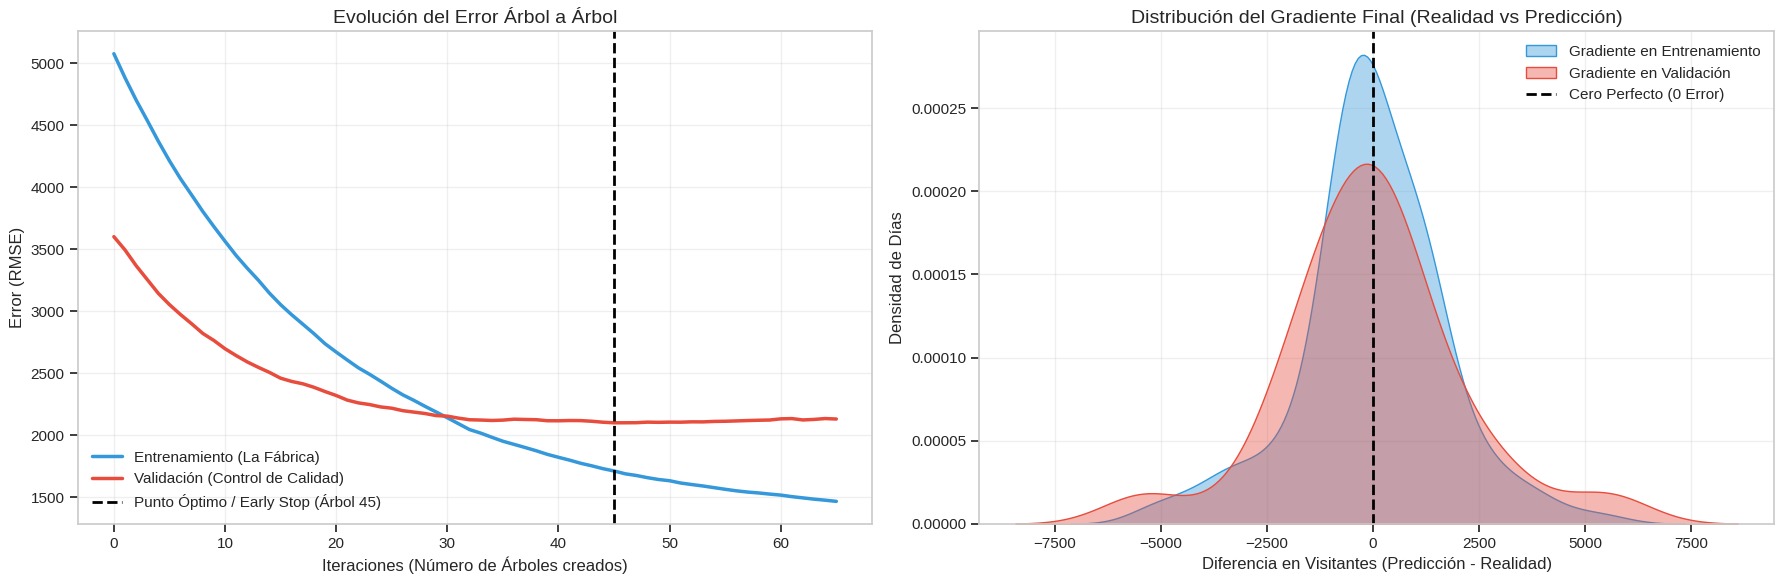

In [5]:

resultados = modelo.evals_result()
epochs = len(resultados['validation_0']['rmse'])
x_axis = range(0, epochs)

pred_train = modelo.predict(X_train)
pred_test = modelo.predict(X_test)

gradiente_train = pred_train - y_train.values
gradiente_test = pred_test - y_test.values


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

ax1.plot(x_axis, resultados['validation_0']['rmse'], label='Entrenamiento (La Fábrica)', color='#3498db', linewidth=2.5)
ax1.plot(x_axis, resultados['validation_1']['rmse'], label='Validación (Control de Calidad)', color='#e74c3c', linewidth=2.5)


ax1.axvline(modelo.best_iteration, color='black', linestyle='--', linewidth=2, 
            label=f'Punto Óptimo / Early Stop (Árbol {modelo.best_iteration})')

ax1.set_title('Evolución del Error Árbol a Árbol', fontsize=14)
ax1.set_xlabel('Iteraciones (Número de Árboles creados)')
ax1.set_ylabel('Error (RMSE)')
ax1.legend()
ax1.grid(True, alpha=0.3)

sns.kdeplot(gradiente_train, ax=ax2, label='Gradiente en Entrenamiento', color='#3498db', fill=True, alpha=0.4)
sns.kdeplot(gradiente_test, ax=ax2, label='Gradiente en Validación', color='#e74c3c', fill=True, alpha=0.4)

ax2.axvline(0, color='black', linestyle='--', linewidth=2, label='Cero Perfecto (0 Error)')
ax2.set_title('Distribución del Gradiente Final (Realidad vs Predicción)', fontsize=14)
ax2.set_xlabel('Diferencia en Visitantes (Predicción - Realidad)')
ax2.set_ylabel('Densidad de Días')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=test['fecha'], 
    y=test['total_visits'],
    mode='lines+markers',
    name='Realidad',
    line=dict(color='black', width=2)
))

fig.add_trace(go.Scatter(
    x=test['fecha'], 
    y=test['prediccion'],
    mode='lines+markers',
    name='Prediccion',
    line=dict(color='#8e44ad', width=2, dash='dot')
))

for index, row in test.iterrows():
    fig.add_trace(go.Scatter(
        x=[row['fecha'], row['fecha']],
        y=[row['total_visits'], row['prediccion']],
        mode='lines',
        line=dict(color='red', width=1, dash='solid'),
        showlegend=False,
        hoverinfo='skip'
    ))

fig.update_layout(
    title=f'Realidad vs Prediccion en {nombre_objetivo}',
    xaxis_title='Fecha',
    yaxis_title='Visitantes',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()